# Uni-Mol Training Record for DN and ESP Models

This notebook preserves the Uni-Mol fine-tuning workflow used for donor number (DN), ESPmin, and ESPmax regression. Source text, comments, and inline messages have been standardized in English. Historical training outputs are retained for provenance, so some legacy console logs may remain in their original language.


#### 1. Dataset loading and train-test split

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

# Resolve paths relative to the repository root.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
UNIMOL_WORKDIR = PROJECT_ROOT / 'outputs' / 'unimol_training'

def work_file(*parts):
    path = UNIMOL_WORKDIR.joinpath(*parts)
    path.parent.mkdir(parents=True, exist_ok=True)
    return str(path)

def work_dir(*parts):
    path = UNIMOL_WORKDIR.joinpath(*parts)
    path.mkdir(parents=True, exist_ok=True)
    return str(path)

# dn_file_path = DATA_DIR / 'donor_number.csv'
esp_file_path = DATA_DIR / 'esp_344.csv'
# op_file_path = DATA_DIR / 'oxidation_potential.csv'
# dn_df = pd.read_csv(dn_file_path)
esp_df = pd.read_csv(esp_file_path)
# op_df = pd.read_csv(op_file_path)



random_state = 3047  # 1




train_esp_df, test_esp_df = train_test_split(
    esp_df, 
    test_size=0.2,           # Use 20% as the test set
    random_state=random_state,  # Random seed
    shuffle=True             # Shuffle before splitting
)






# train_dn_path = r'D:\Project\Code\unimol_tools\dataset\Donor Number\train_dn_set.csv'
# test_dn_path = r'D:\Project\Code\unimol_tools\dataset\Donor Number\test_dn_set.csv'
train_esp_path = work_file('dataset', 'ESP', 'train_esp_set.csv')
test_esp_path = work_file('dataset', 'ESP', 'test_esp_set.csv')
# train_op_path = r'D:\Project\Code\unimol_tools\dataset\Oxidation Potential\train_op_set.csv'
# test_op_path = r'D:\Project\Code\unimol_tools\dataset\Oxidation Potential\test_op_set.csv'

# train_dn_df.to_csv(train_dn_path, index=False)
# test_dn_df.to_csv(test_dn_path, index=False)
train_esp_df.to_csv(train_esp_path, index=False)
test_esp_df.to_csv(test_esp_path, index=False)
# train_op_df.to_csv(train_op_path, index=False)
# test_op_df.to_csv(test_op_path, index=False)


成功读取ESP数据集, 数据形状: (344, 3)
数据集包含 344 行, 3 列

数据划分完成:
-----------------------------------------------------------------
原始ESP数据集大小: 344
训练集大小: 275 (79.9%)
测试集大小: 69 (20.1%)
-----------------------------------------------------------------

ESP 训练集已保存到: /home/hank/code/unimol_tools/dataset/ESP/train_esp_set.csv
ESP 测试集已保存到: /home/hank/code/unimol_tools/dataset/ESP/test_esp_set.csv


### 2. Donor number prediction

#### 2.1 Two-stage DN model fine-tuning

In [ ]:
from unimol_tools import MolTrain, MolPredict
import numpy as np

clf = MolTrain(
    task='regression',
    model_name='unimolv1',
    model_size='84m',
    epochs=100,
    learning_rate=1e-3,
    batch_size=8,
    early_stopping=20,
    metrics='mae',
    split='random',
    kfold=5,
    # Stage 1: freeze the Uni-Mol backbone and train only the prediction head.
    freeze_layers = ['embed_tokens', 'encoder', 'gbf', 'gbf_proj'],
    freeze_layers_reversed=False,
    save_path=work_dir('Result', 'Donor Number', 'fold_5', 'pretrain'),
)

train_file_path = work_file('dataset', 'Donor Number', 'train_dn_set.csv')


clf.fit(data = train_file_path)

2025-06-05 16:58:20 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...
156it [00:00, 646.57it/s]
2025-06-05 16:58:20 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 100.00% of molecules.
2025-06-05 16:58:20 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 98.72% of molecules.
2025-06-05 16:58:20 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [41, 147]
2025-06-05 16:58:20 | unimol_tools/data/datahub.py | 182 | WARNING | Uni-Mol Tools | conf_cache_level is 1, but /home/hank/code/unimol_tools/Result/Donor Number/fold_5/pretrain/train_dn_set.sdf exists, so do not save conformers.
2025-06-05 16:58:20 | unimol_tools/data/datahub.py | 150 | INFO | Uni-Mol Tools | Split method: random, fold: 5
2025-06-05 16:58:20 | unimol_tools/train.py | 223 | INFO | Uni-Mol Tools | Output directory already ex

In [ ]:
from unimol_tools import MolTrain, MolPredict
import numpy as np


clf = MolTrain(
    task='regression',
    model_name='unimolv1',
    model_size='84m',
    epochs=200,
    learning_rate=1e-4,

    max_norm = 5.0,
    batch_size=8,
    early_stopping=20,
    metrics='mae',
    split='random',
    kfold=5,
    # Stage 2: load the stage-1 checkpoint and fine-tune selected layers.
    # freeze_layers = ['embed_tokens','encoder','classification_head'],
    # freeze_layers_reversed=True,
    # 
    load_model_dir = work_dir('Result', 'Donor Number', 'fold_5', 'pretrain'),
    save_path=work_dir('Result', 'Donor Number', 'fold_5', 'final'),
)

train_file_path = work_file('dataset', 'Donor Number', 'train_dn_set.csv')

# Train the model
clf.fit(data = train_file_path)

2025-06-05 16:59:48 | unimol_tools/train.py | 127 | INFO | Uni-Mol Tools | Load config file from /home/hank/code/unimol_tools/Result/Donor Number/fold_5/pretrain/config.yaml
2025-06-05 16:59:48 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...
156it [00:00, 644.88it/s]
2025-06-05 16:59:49 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 100.00% of molecules.
2025-06-05 16:59:49 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 98.72% of molecules.
2025-06-05 16:59:49 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [41, 147]
2025-06-05 16:59:49 | unimol_tools/data/datahub.py | 182 | WARNING | Uni-Mol Tools | conf_cache_level is 1, but /home/hank/code/unimol_tools/Result/Donor Number/fold_5/final/train_dn_set.sdf exists, so do not save conformers.
2025-06-05 16:59:49 | unimol_tools/data/dat

#### 2.2 DN prediction on training and test sets

In [ ]:
from unimol_tools import MolTrain, MolPredict
import numpy as np


clf = MolPredict(load_model = work_dir('Result', 'Donor Number', 'fold_5', 'final'))
train_file_path = work_file('dataset', 'Donor Number', 'train_dn_set.csv')
test_file_path = work_file('dataset', 'Donor Number', 'test_dn_set.csv')
predict_train = clf.predict(data = train_file_path)
predict_test = clf.predict(data = test_file_path)

2026-05-16 13:19:12 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...
156it [00:00, 660.99it/s]
2026-05-16 13:19:13 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 100.00% of molecules.
2026-05-16 13:19:13 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 98.72% of molecules.
2026-05-16 13:19:13 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [41, 147]
2026-05-16 13:19:13 | unimol_tools/data/datahub.py | 182 | WARNING | Uni-Mol Tools | conf_cache_level is 1, but /home/hank/code/unimol_tools/Result/Donor Number/fold_5/final/train_dn_set.sdf exists, so do not save conformers.
2026-05-16 13:19:13 | unimol_tools/tasks/trainer.py | 78 | INFO | Uni-Mol Tools | Number of GPUs available: 1
2026-05-16 13:19:13 | unimol_tools/tasks/trainer.py | 98 | INFO | Uni-Mol Tools | Using single GPU.
2026-05

#### 2.3 Saving DN prediction results

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


train_df = pd.read_csv(train_file_path)
test_df = pd.read_csv(test_file_path)

target_column = 'TARGET_Donor Number'
true_values_train = train_df[target_column]
true_values_test = test_df[target_column]

predict_values_train = predict_train.flatten()
predict_values_test = predict_test.flatten()

results_train_df = pd.DataFrame({
    'True Values': true_values_train,
    'Predicted Values': predict_values_train
})
results_test_df = pd.DataFrame({
    'True Values': true_values_test,
    'Predicted Values': predict_values_test
})

output_train_path = work_file('predict_dataset', 'donor_number', 'train_predict.csv')
output_test_path = work_file('predict_dataset', 'donor_number', 'test_predict.csv')
results_train_df.to_csv(output_train_path, index=False)
results_test_df.to_csv(output_test_path, index=False)

#### 2.4 DN parity plot and error metrics

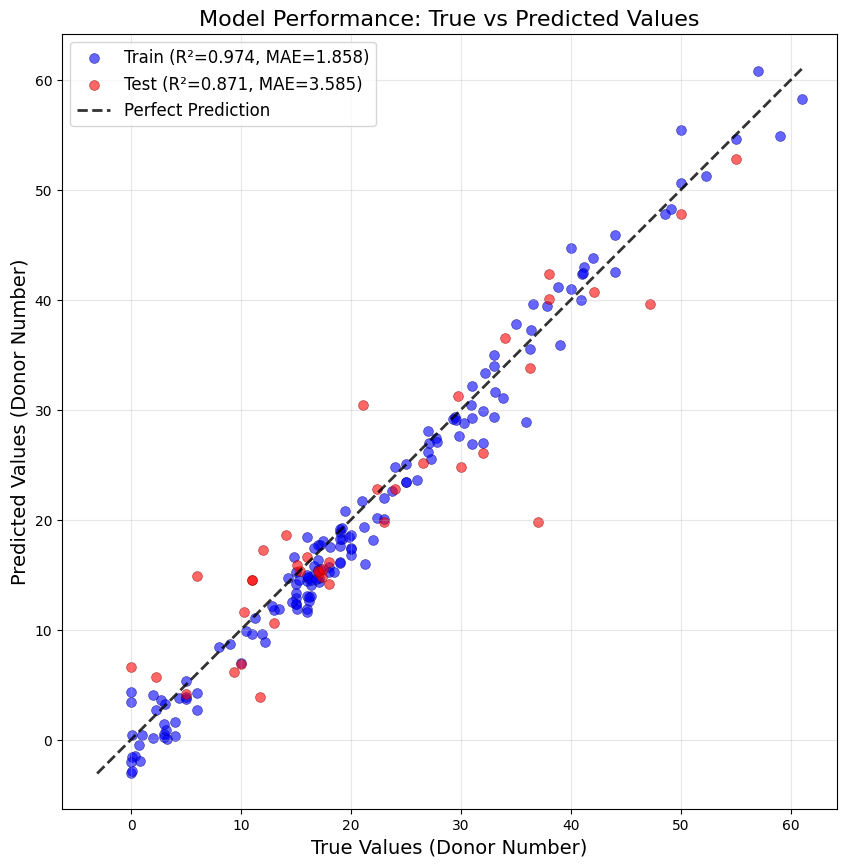

模型性能评估
训练集 (蓝色点):
  R² Score: 0.9737
  MAE: 1.8578
  RMSE: 2.2495
  样本数: 156

测试集 (红色点):
  R² Score: 0.8707
  MAE: 3.5849
  RMSE: 4.7988
  样本数: 39

整体性能:
  R² Score: 0.9544
  MAE: 2.2032
  RMSE: 2.9418
  总样本数: 195

图片已保存到: /home/hank/code/unimol_tools/predict dataset/donor number/combined_true_vs_predict.png

模型分析:
  训练集R²比测试集高 0.1030
  可能存在一定程度的过拟合


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Calculate evaluation metrics.
def calculate_metrics(true_vals, pred_vals):
    r2 = r2_score(true_vals, pred_vals)
    mae = mean_absolute_error(true_vals, pred_vals)
    rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    return r2, mae, rmse


r2_train, mae_train, rmse_train = calculate_metrics(true_values_train, predict_values_train)
r2_test, mae_test, rmse_test = calculate_metrics(true_values_test, predict_values_test)


plt.figure(figsize=(10, 16))


plt.scatter(true_values_train, predict_values_train, 
           alpha=0.6, s=50, color='blue', edgecolors='navy', linewidth=0.5,
           label=f'Train (R²={r2_train:.3f}, MAE={mae_train:.3f})')


plt.scatter(true_values_test, predict_values_test, 
           alpha=0.6, s=50, color='red', edgecolors='darkred', linewidth=0.5,
           label=f'Test (R²={r2_test:.3f}, MAE={mae_test:.3f})')


all_true = np.concatenate([true_values_train, true_values_test])
all_pred = np.concatenate([predict_values_train, predict_values_test])
min_val = min(min(all_true), min(all_pred))
max_val = max(max(all_true), max(all_pred))


plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, alpha=0.8, label='Perfect Prediction')


plt.xlabel('True Values (Donor Number)', fontsize=14)
plt.ylabel('Predicted Values (Donor Number)', fontsize=14)
plt.title('Model Performance: True vs Predicted Values', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)


margin = (max_val - min_val) * 0.05
plt.xlim(min_val - margin, max_val + margin)
plt.ylim(min_val - margin, max_val + margin)


plt.gca().set_aspect('equal', adjustable='box')


output_image_path = work_file('predict_dataset', 'donor_number', 'combined_true_vs_predict.png')
plt.savefig(output_image_path, dpi=300, bbox_inches='tight')


plt.show()


print("="*60)
print("Model performance evaluation")
print("="*60)
print(f"Training set (blue points):")
print(f"  R² Score: {r2_train:.4f}")
print(f"  MAE: {mae_train:.4f}")
print(f"  RMSE: {rmse_train:.4f}")
print(f"  Sample count: {len(true_values_train)}")

print(f"\nTest set (red points):")
print(f"  R² Score: {r2_test:.4f}")
print(f"  MAE: {mae_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  Sample count: {len(true_values_test)}")


r2_overall, mae_overall, rmse_overall = calculate_metrics(all_true, all_pred)
print(f"\nOverall performance:")
print(f"  R² Score: {r2_overall:.4f}")
print(f"  MAE: {mae_overall:.4f}")
print(f"  RMSE: {rmse_overall:.4f}")
print(f"  Total sample count: {len(all_true)}")

print(f"\nFigure saved to: {output_image_path}")


if r2_train > r2_test:
    overfitting = r2_train - r2_test
    print(f"\nModel analysis:")
    print(f"  Training-set R2 exceeds test-set R2 by {overfitting:.4f}")
    if overfitting > 0.1:
        print("  Some degree of overfitting may be present")
    else:
        print("  The model shows good generalization")
else:
    print(f"\nModel analysis:")
    print("  Test-set performance is not lower than training-set performance, indicating good generalization")

### 3. Multi-target ESP prediction

#### 3.1 Two-stage multi-target ESP model fine-tuning

In [ ]:
from unimol_tools import MolTrain, MolPredict
import numpy as np

clf = MolTrain(
    task='multilabel_regression',
    model_name='unimolv1',
    model_size='84m',
    epochs=200,
    learning_rate=1e-3,  
    batch_size=8,
    early_stopping=15,
    metrics='mae',
    split='random',
    kfold=3,
    # Stage 1: freeze the Uni-Mol backbone and train only the prediction head.
    freeze_layers = ['embed_tokens', 'encoder', 'gbf', 'gbf_proj'],
    freeze_layers_reversed=False,
    save_path=work_dir('Result', 'ESP', 'fold_5', 'pretrain'),
)

train_esp_file_path = work_file('dataset', 'ESP', 'train_esp_set_new.csv')


clf.fit(data = train_esp_file_path)

2025-06-05 16:35:59 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...
133it [00:00, 998.39it/s]
2025-06-05 16:35:59 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 100.00% of molecules.
2025-06-05 16:35:59 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 99.25% of molecules.
2025-06-05 16:35:59 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [117]
2025-06-05 16:35:59 | unimol_tools/data/datahub.py | 182 | WARNING | Uni-Mol Tools | conf_cache_level is 1, but /home/hank/code/unimol_tools/Result/ESP/fold_5/pretrain/train_esp_set_new.sdf exists, so do not save conformers.
2025-06-05 16:35:59 | unimol_tools/data/datahub.py | 150 | INFO | Uni-Mol Tools | Split method: random, fold: 3
2025-06-05 16:35:59 | unimol_tools/train.py | 223 | INFO | Uni-Mol Tools | Output directory already exists: /h

In [ ]:
from unimol_tools import MolTrain, MolPredict
import numpy as np

clf = MolTrain(
    task='multilabel_regression',
    model_name='unimolv1',
    model_size='84m',
    epochs=200,
    learning_rate=1e-4,  
    batch_size=8,
    early_stopping=15,
    metrics='mae',
    split='random',
    kfold=3,
    
    freeze_layers = ['embed_tokens','encoder','classification_head'],
    freeze_layers_reversed=True,
  
    load_model_dir = work_dir('Result', 'ESP', 'fold_5', 'pretrain'),
    save_path=work_dir('Result', 'ESP', 'fold_5', 'final'),
)

train_esp_file_path = work_file('dataset', 'ESP', 'train_esp_set_new.csv')


clf.fit(data = train_esp_file_path)

2025-06-05 16:38:43 | unimol_tools/train.py | 127 | INFO | Uni-Mol Tools | Load config file from /home/hank/code/unimol_tools/Result/ESP/fold_5/pretrain/config.yaml
2025-06-05 16:38:43 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...
133it [00:00, 1013.35it/s]
2025-06-05 16:38:43 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 100.00% of molecules.
2025-06-05 16:38:43 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 99.25% of molecules.
2025-06-05 16:38:43 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [117]
2025-06-05 16:38:43 | unimol_tools/data/datahub.py | 182 | WARNING | Uni-Mol Tools | conf_cache_level is 1, but /home/hank/code/unimol_tools/Result/ESP/fold_5/final/train_esp_set_new.sdf exists, so do not save conformers.
2025-06-05 16:38:43 | unimol_tools/data/datahub.py | 150 | 

#### 3.2 ESP prediction on training and test sets

In [27]:
clf = MolPredict(load_model = work_dir('Result', 'ESP', 'fold_5', 'final'))

train_file_path = work_file('dataset', 'ESP', 'train_esp_set_new.csv')
test_file_path = work_file('dataset', 'ESP', 'test_esp_set_new.csv')

predict_train_esp = clf.predict(data = train_file_path)
predict_test_esp = clf.predict(data = test_file_path)

2025-06-05 16:40:15 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...
133it [00:00, 979.11it/s]
2025-06-05 16:40:16 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 100.00% of molecules.
2025-06-05 16:40:16 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 99.25% of molecules.
2025-06-05 16:40:16 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [117]
2025-06-05 16:40:16 | unimol_tools/data/datahub.py | 182 | WARNING | Uni-Mol Tools | conf_cache_level is 1, but /home/hank/code/unimol_tools/Result/ESP/fold_5/final/train_esp_set_new.sdf exists, so do not save conformers.
2025-06-05 16:40:16 | unimol_tools/tasks/trainer.py | 78 | INFO | Uni-Mol Tools | Number of GPUs available: 1
2025-06-05 16:40:16 | unimol_tools/tasks/trainer.py | 98 | INFO | Uni-Mol Tools | Using single GPU.
2025-06-05 16:4

#### 3.3 Saving multi-target ESP prediction results

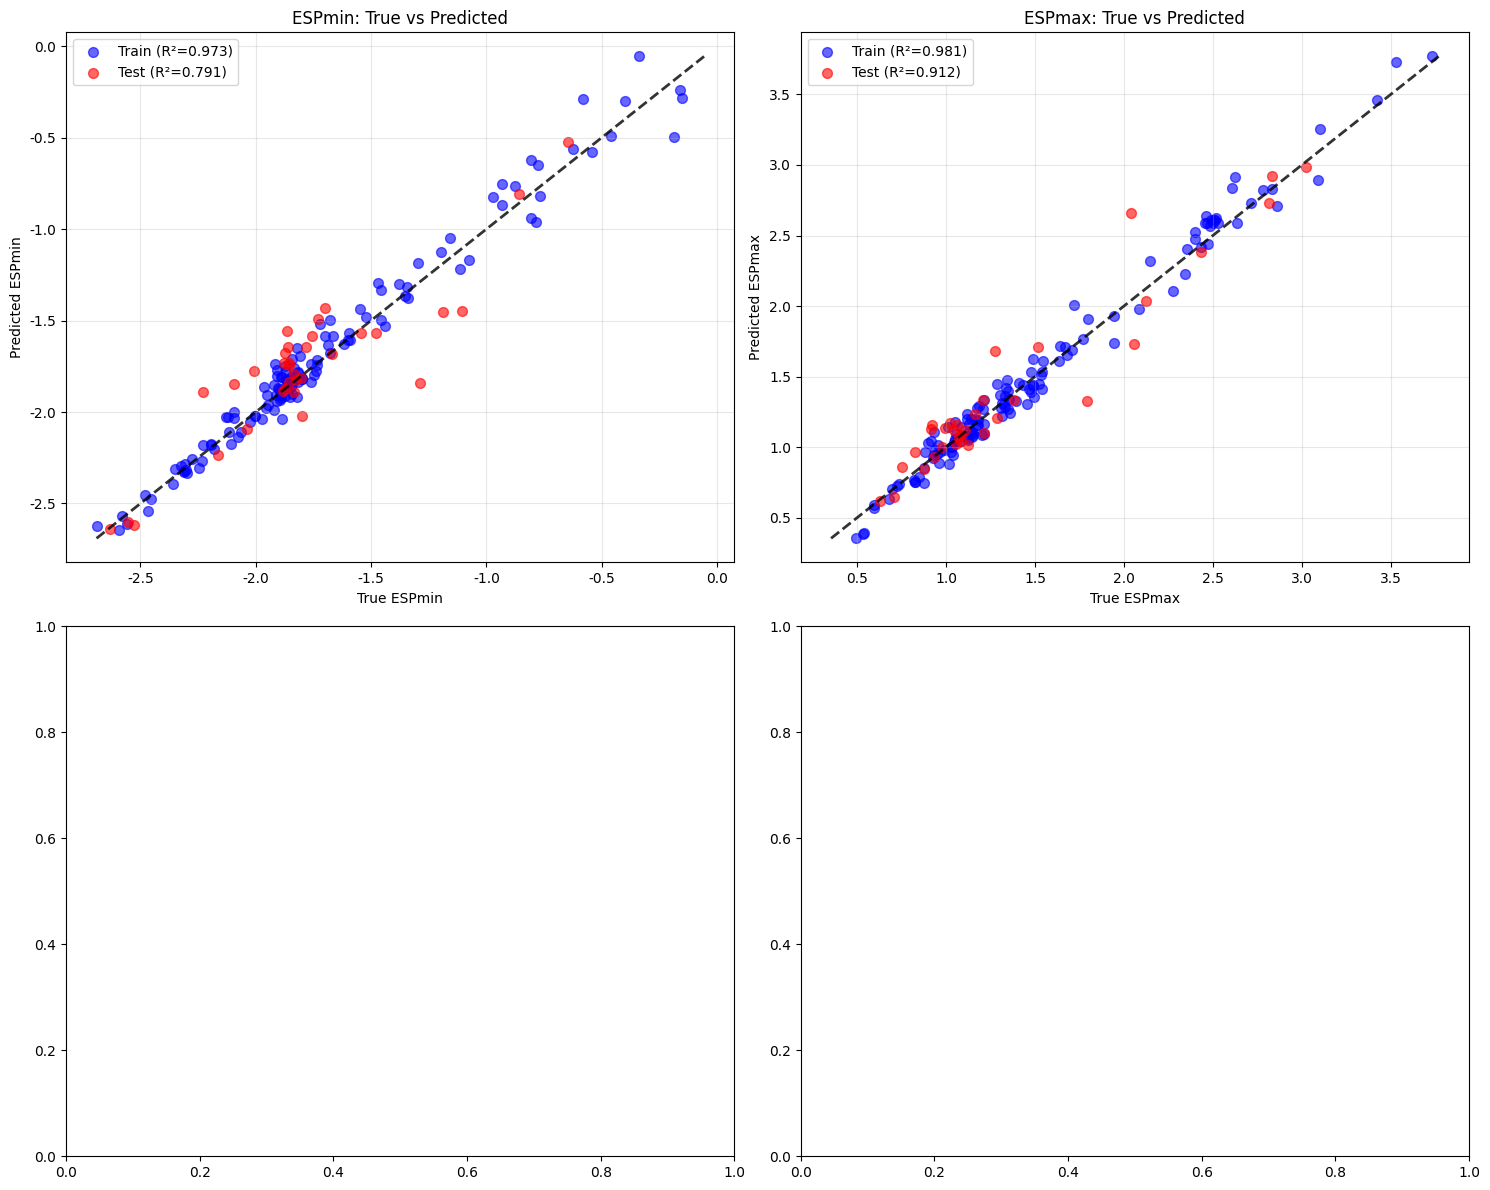

ESP多目标回归模型性能评估

【ESPmin 性能】
训练集:
  R² Score: 0.9728
  MAE: 0.0650
  RMSE: 0.0880
测试集:
  R² Score: 0.7908
  MAE: 0.1418
  RMSE: 0.1903

【ESPmax 性能】
训练集:
  R² Score: 0.9809
  MAE: 0.0760
  RMSE: 0.0961
测试集:
  R² Score: 0.9122
  MAE: 0.1265
  RMSE: 0.1869

【整体平均性能】
训练集平均 R²: 0.9768
测试集平均 R²: 0.8515
训练集平均 MAE: 0.0705
测试集平均 MAE: 0.1341

样本数:
  训练集: 133
  测试集: 34

文件保存位置:
  训练集预测结果: /home/hank/code/unimol_tools/predict dataset/ESP/train_esp_predict.csv
  测试集预测结果: /home/hank/code/unimol_tools/predict dataset/ESP/test_esp_predict.csv
  可视化图片: /home/hank/code/unimol_tools/predict dataset/ESP/esp_multilabel_analysis.png

【模型分析】
ESPmin 相对更难预测 (测试集R²: 0.7908 vs 0.9122)


In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set font fallback for plot rendering
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Read the split datasets and match predictions with ground-truth values.
train_df = pd.read_csv(train_file_path)
test_df = pd.read_csv(test_file_path)

# Target column names
target_columns = ['TARGET_ESPmin', 'TARGET_ESPmax']

# Extract ground-truth values
true_train_espmin = train_df[target_columns[0]].values
true_train_espmax = train_df[target_columns[1]].values
true_test_espmin = test_df[target_columns[0]].values
true_test_espmax = test_df[target_columns[1]].values

# Extract predictions for the two targets
pred_train_espmin = predict_train_esp[:, 0]  # First column: ESPmin
pred_train_espmax = predict_train_esp[:, 1]  # Second column: ESPmax
pred_test_espmin = predict_test_esp[:, 0]    # First column: ESPmin
pred_test_espmax = predict_test_esp[:, 1]    # Second column: ESPmax

# Calculate evaluation metrics.
def calculate_metrics(true_vals, pred_vals):
    r2 = r2_score(true_vals, pred_vals)
    mae = mean_absolute_error(true_vals, pred_vals)
    rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    return r2, mae, rmse

# Calculate metrics for ESPmin and ESPmax separately
# ESPmin metrics
r2_train_min, mae_train_min, rmse_train_min = calculate_metrics(true_train_espmin, pred_train_espmin)
r2_test_min, mae_test_min, rmse_test_min = calculate_metrics(true_test_espmin, pred_test_espmin)

# ESPmax metrics
r2_train_max, mae_train_max, rmse_train_max = calculate_metrics(true_train_espmax, pred_train_espmax)
r2_test_max, mae_test_max, rmse_test_max = calculate_metrics(true_test_espmax, pred_test_espmax)

# Create result DataFrames
results_train_df = pd.DataFrame({
    'True_ESPmin': true_train_espmin,
    'Pred_ESPmin': pred_train_espmin,
    'True_ESPmax': true_train_espmax,
    'Pred_ESPmax': pred_train_espmax
})

results_test_df = pd.DataFrame({
    'True_ESPmin': true_test_espmin,
    'Pred_ESPmin': pred_test_espmin,
    'True_ESPmax': true_test_espmax,
    'Pred_ESPmax': pred_test_espmax
})

# Save results
output_train_path = work_file('predict_dataset', 'ESP', 'train_esp_predict.csv')
output_test_path = work_file('predict_dataset', 'ESP', 'test_esp_predict.csv')
results_train_df.to_csv(output_train_path, index=False)
results_test_df.to_csv(output_test_path, index=False)

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ESPmin: training set vs test set
ax1 = axes[0, 0]
ax1.scatter(true_train_espmin, pred_train_espmin, alpha=0.6, s=50, color='blue', 
           label=f'Train (R²={r2_train_min:.3f})')
ax1.scatter(true_test_espmin, pred_test_espmin, alpha=0.6, s=50, color='red', 
           label=f'Test (R²={r2_test_min:.3f})')
min_val = min(min(true_train_espmin), min(true_test_espmin), min(pred_train_espmin), min(pred_test_espmin))
max_val = max(max(true_train_espmin), max(true_test_espmin), max(pred_train_espmin), max(pred_test_espmin))
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, alpha=0.8)
ax1.set_xlabel('True ESPmin')
ax1.set_ylabel('Predicted ESPmin')
ax1.set_title('ESPmin: True vs Predicted')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ESPmax: training set vs test set
ax2 = axes[0, 1]
ax2.scatter(true_train_espmax, pred_train_espmax, alpha=0.6, s=50, color='blue', 
           label=f'Train (R²={r2_train_max:.3f})')
ax2.scatter(true_test_espmax, pred_test_espmax, alpha=0.6, s=50, color='red', 
           label=f'Test (R²={r2_test_max:.3f})')
min_val = min(min(true_train_espmax), min(true_test_espmax), min(pred_train_espmax), min(pred_test_espmax))
max_val = max(max(true_train_espmax), max(true_test_espmax), max(pred_train_espmax), max(pred_test_espmax))
ax2.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, alpha=0.8)
ax2.set_xlabel('True ESPmax')
ax2.set_ylabel('Predicted ESPmax')
ax2.set_title('ESPmax: True vs Predicted')
ax2.legend()
ax2.grid(True, alpha=0.3)


plt.tight_layout()
output_image_path = work_file('predict_dataset', 'ESP', 'esp_multilabel_analysis.png')
plt.savefig(output_image_path, dpi=300, bbox_inches='tight')
plt.show()

# Print detailed evaluation results
print("="*70)
print("ESP multi-target regression model performance evaluation")
print("="*70)

print("\n[ESPmin performance]")
print(f"Training set:")
print(f"  R² Score: {r2_train_min:.4f}")
print(f"  MAE: {mae_train_min:.4f}")
print(f"  RMSE: {rmse_train_min:.4f}")
print(f"Test set:")
print(f"  R² Score: {r2_test_min:.4f}")
print(f"  MAE: {mae_test_min:.4f}")
print(f"  RMSE: {rmse_test_min:.4f}")

print("\n[ESPmax performance]")
print(f"Training set:")
print(f"  R² Score: {r2_train_max:.4f}")
print(f"  MAE: {mae_train_max:.4f}")
print(f"  RMSE: {rmse_train_max:.4f}")
print(f"Test set:")
print(f"  R² Score: {r2_test_max:.4f}")
print(f"  MAE: {mae_test_max:.4f}")
print(f"  RMSE: {rmse_test_max:.4f}")

# Calculate average performance
avg_r2_train = (r2_train_min + r2_train_max) / 2
avg_r2_test = (r2_test_min + r2_test_max) / 2
avg_mae_train = (mae_train_min + mae_train_max) / 2
avg_mae_test = (mae_test_min + mae_test_max) / 2

print("\n[Overall average performance]")
print(f"Average training-set R2: {avg_r2_train:.4f}")
print(f"Average test-set R2: {avg_r2_test:.4f}")
print(f"Average training-set MAE: {avg_mae_train:.4f}")
print(f"Average test-set MAE: {avg_mae_test:.4f}")

print(f"\nSample count:")
print(f"  Training set: {len(true_train_espmin)}")
print(f"  Test set: {len(true_test_espmin)}")

print(f"\nSaved files:")
print(f"  Training-set predictions: {output_train_path}")
print(f"  Test-set predictions: {output_test_path}")
print(f"  Visualization figure: {output_image_path}")

# Analyze which target is more difficult to predict
if r2_test_min < r2_test_max:
    print(f"\n[Model analysis]")
    print(f"ESPmin is relatively more difficult to predict (test-set R2: {r2_test_min:.4f} vs {r2_test_max:.4f})")
else:
    print(f"\n[Model analysis]")
    print(f"ESPmax is relatively more difficult to predict (test-set R2: {r2_test_max:.4f} vs {r2_test_min:.4f})")

#### 4. Single-target ESP prediction

##### 4.1 Splitting ESPmin and ESPmax into separate datasets

In [4]:
import pandas as pd
import os

def split_esp_dataset(input_file, output_dir=None):
    """
    Split a dataset containing SMILES, TARGET_ESPmin, and TARGET_ESPmax into two single-target datasets.
    
    Args:
        input_file: Path to the input CSV file.
        output_dir: Output directory. If None, the input file directory is used.
    """
    
    # Read the original dataset
    df = pd.read_csv(input_file)
    
    # Check whether required columns are present
    required_columns = ['SMILES', 'TARGET_ESPmin', 'TARGET_ESPmax']
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")
    
    print(f"Original data shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    
    # Create two single-target datasets
    df_min = df[['SMILES', 'TARGET_ESPmin']].copy()
    df_max = df[['SMILES', 'TARGET_ESPmax']].copy()
    
    # Set the output directory
    if output_dir is None:
        output_dir = os.path.dirname(input_file)
    
    # Ensure that the output directory exists
    os.makedirs(output_dir, exist_ok=True)
    
    # Generate output file names
    base_name = os.path.splitext(os.path.basename(input_file))[0]
    output_min_file = os.path.join(output_dir, f"{base_name}_ESPmin.csv")
    output_max_file = os.path.join(output_dir, f"{base_name}_ESPmax.csv")
    
    # Save files
    df_min.to_csv(output_min_file, index=False)
    df_max.to_csv(output_max_file, index=False)
    
    print(f"\nDataset splitting completed!")
    print(f"ESPmin dataset: {output_min_file} (shape: {df_min.shape})")
    print(f"ESPmax dataset: {output_max_file} (shape: {df_max.shape})")
    
    return output_min_file, output_max_file

# File paths
input_train_file = work_file('dataset', 'ESP', 'train_esp_set.csv')
input_test_file = work_file('dataset', 'ESP', 'test_esp_set.csv')

try:
    # Run the split
    esp_min_train_file, esp_max_train_file = split_esp_dataset(input_train_file)
    esp_min_test_file, esp_max_test_file = split_esp_dataset(input_test_file)
    
except Exception as e:
    print(f"An error occurred during processing: {e}")

原始数据形状: (276, 3)
列名: ['SMILES', 'TARGET_ESPmin', 'TARGET_ESPmax']

拆分完成!
ESPmin数据集: /home/hank/code/unimol_tools/dataset/ESP/train_esp_set_ESPmin.csv (形状: (276, 2))
ESPmax数据集: /home/hank/code/unimol_tools/dataset/ESP/train_esp_set_ESPmax.csv (形状: (276, 2))
原始数据形状: (69, 3)
列名: ['SMILES', 'TARGET_ESPmin', 'TARGET_ESPmax']

拆分完成!
ESPmin数据集: /home/hank/code/unimol_tools/dataset/ESP/test_esp_set_ESPmin.csv (形状: (69, 2))
ESPmax数据集: /home/hank/code/unimol_tools/dataset/ESP/test_esp_set_ESPmax.csv (形状: (69, 2))


#### 4.2 ESPmin model fine-tuning

In [12]:
from unimol_tools import MolTrain, MolPredict
import numpy as np

clf = MolTrain(
    task='regression',
    model_name='unimolv1',
    model_size='84m',
    epochs=300,
    learning_rate=1e-3,  
    batch_size=8,
    early_stopping=15,
    metrics='mae',
    split='random',
    kfold=5,
    max_norm=5.0,
    # Train only the classification head
    freeze_layers = ['embed_tokens', 'encoder', 'gbf', 'gbf_proj'],
    freeze_layers_reversed=False,
    save_path=work_dir('Result', 'ESP', 'single_target', 'espmin', 'pretrain'),
)

train_esp_file_path = work_file('dataset', 'ESP', 'train_esp_set_ESPmin.csv')

# Train the model
clf.fit(data = train_esp_file_path)

2025-09-01 13:56:43 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...


276it [00:00, 600.49it/s]
2025-09-01 13:56:43 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 100.00% of molecules.
2025-09-01 13:56:43 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 99.64% of molecules.
2025-09-01 13:56:43 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [228]
2025-09-01 13:56:43 | unimol_tools/data/datahub.py | 182 | WARNING | Uni-Mol Tools | conf_cache_level is 1, but /home/hank/code/unimol_tools/Result/ESP/single target/espmin/pretrain/train_esp_set_ESPmin.sdf exists, so do not save conformers.
2025-09-01 13:56:43 | unimol_tools/data/datahub.py | 150 | INFO | Uni-Mol Tools | Split method: random, fold: 5
2025-09-01 13:56:43 | unimol_tools/train.py | 223 | INFO | Uni-Mol Tools | Output directory already exists: /home/hank/code/unimol_tools/Result/ESP/single target/espmin/pretrain
2025-09-01 13:56:43 | unimol_t

In [13]:
from unimol_tools import MolTrain, MolPredict
import numpy as np

clf = MolTrain(
    task='regression',
    model_name='unimolv1',
    model_size='84m',
    epochs=200,
    learning_rate=1e-4,  
    batch_size=8,
    early_stopping=30,
    metrics='mae',
    split='random',
    kfold=5,
    max_norm=5.0,
    # Load the pretrained model
    load_model_dir = work_dir('Result', 'ESP', 'single_target', 'espmin', 'pretrain'),
     # Unfreeze selected layers
    freeze_layers = ['embed_tokens','encoder','classification_head'],
    freeze_layers_reversed=True,
    save_path=work_dir('Result', 'ESP', 'single_target', 'espmin', 'final'),
)

train_esp_file_path = work_file('dataset', 'ESP', 'train_esp_set_ESPmin.csv')

# Train the model
clf.fit(data = train_esp_file_path)

2025-09-01 14:00:22 | unimol_tools/train.py | 127 | INFO | Uni-Mol Tools | Load config file from /home/hank/code/unimol_tools/Result/ESP/single target/espmin/pretrain/config.yaml
2025-09-01 14:00:22 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...
276it [00:00, 598.90it/s]
2025-09-01 14:00:22 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 100.00% of molecules.
2025-09-01 14:00:22 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 99.64% of molecules.
2025-09-01 14:00:22 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [228]
2025-09-01 14:00:22 | unimol_tools/data/datahub.py | 182 | WARNING | Uni-Mol Tools | conf_cache_level is 1, but /home/hank/code/unimol_tools/Result/ESP/single target/espmin/final/train_esp_set_ESPmin.sdf exists, so do not save conformers.
2025-09-01 14:00:22 | unimol_

##### 4.3 ESPmin prediction and evaluation

In [20]:
from unimol_tools import MolTrain, MolPredict
import numpy as np

clf = MolPredict(load_model = work_dir('Result', 'ESP', 'single_target', 'espmin', 'final'))

train_esp_min_file_path = work_file('dataset', 'ESP', 'train_esp_set_ESPmin.csv')
test_esp_min_file_path = work_file('dataset', 'ESP', 'test_esp_set_ESPmin.csv')

predict_train_esp_min = clf.predict(data = train_esp_min_file_path)
predict_test_esp_min = clf.predict(data = test_esp_min_file_path)


2025-09-01 14:14:54 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...


276it [00:00, 599.66it/s]
2025-09-01 14:14:54 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 100.00% of molecules.
2025-09-01 14:14:54 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 99.64% of molecules.
2025-09-01 14:14:54 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [228]
2025-09-01 14:14:54 | unimol_tools/data/datahub.py | 182 | WARNING | Uni-Mol Tools | conf_cache_level is 1, but /home/hank/code/unimol_tools/Result/ESP/single target/espmin/final/train_esp_set_ESPmin.sdf exists, so do not save conformers.
2025-09-01 14:14:54 | unimol_tools/tasks/trainer.py | 78 | INFO | Uni-Mol Tools | Number of GPUs available: 1
2025-09-01 14:14:54 | unimol_tools/tasks/trainer.py | 98 | INFO | Uni-Mol Tools | Using single GPU.
2025-09-01 14:14:55 | unimol_tools/models/unimol.py | 136 | INFO | Uni-Mol Tools | Loading pretrained weights fro

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Read prediction results and ground-truth values
train_df = pd.read_csv(train_esp_min_file_path)
test_df = pd.read_csv(test_esp_min_file_path)

target_column = 'TARGET_ESPmin'
true_values_train = train_df[target_column]
true_values_test = test_df[target_column]

predict_values_train = predict_train_esp_min.flatten()
predict_values_test = predict_test_esp_min.flatten()

results_train_df = pd.DataFrame({
    'True Values': true_values_train,
    'Predicted Values': predict_values_train
})
results_test_df = pd.DataFrame({
    'True Values': true_values_test,
    'Predicted Values': predict_values_test
})

output_train_path = work_file('predict_dataset', 'ESP', 'single', 'ESPmin', 'train_predict.csv')
output_test_path = work_file('predict_dataset', 'ESP', 'single', 'ESPmin', 'test_predict.csv')
results_train_df.to_csv(output_train_path, index=False)
results_test_df.to_csv(output_test_path, index=False)

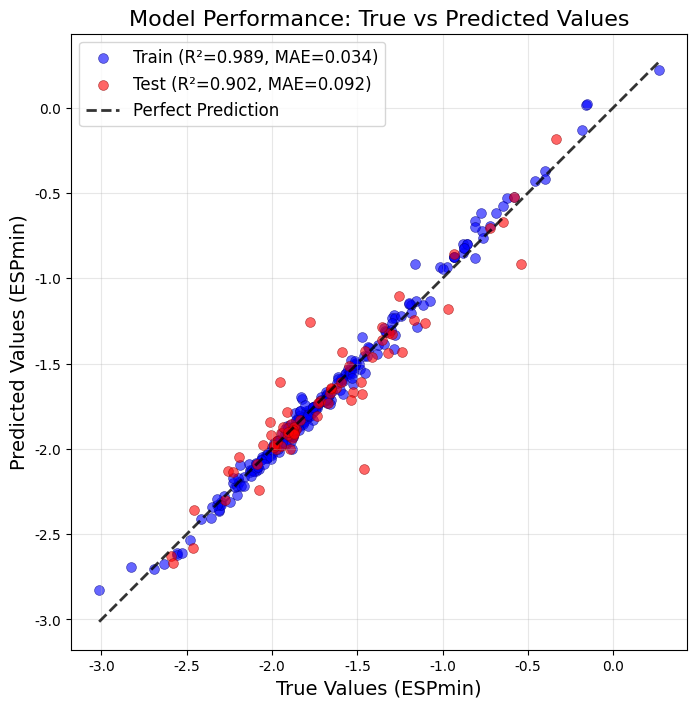

模型性能评估
训练集 (蓝色点):
  R² Score: 0.9893
  MAE: 0.0336
  RMSE: 0.0489
  样本数: 276

测试集 (红色点):
  R² Score: 0.9019
  MAE: 0.0917
  RMSE: 0.1483
  样本数: 68

整体性能:
  R² Score: 0.9720
  MAE: 0.0450
  RMSE: 0.0792
  总样本数: 344

图片已保存到: /home/hank/code/unimol_tools/predict dataset/ESP/single/ESPmin/combined_true_vs_predict.png

模型分析:
  训练集R²比测试集高 0.0874
  模型泛化性能良好


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set font fallback for plot rendering
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Calculate evaluation metrics.
def calculate_metrics(true_vals, pred_vals):
    r2 = r2_score(true_vals, pred_vals)
    mae = mean_absolute_error(true_vals, pred_vals)
    rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    return r2, mae, rmse

# Calculate metrics for the training and test sets
r2_train, mae_train, rmse_train = calculate_metrics(true_values_train, predict_values_train)
r2_test, mae_test, rmse_test = calculate_metrics(true_values_test, predict_values_test)

# Create a single figure
plt.figure(figsize=(10, 8))

# Plot the training set
plt.scatter(true_values_train, predict_values_train, 
           alpha=0.6, s=50, color='blue', edgecolors='navy', linewidth=0.5,
           label=f'Train (R²={r2_train:.3f}, MAE={mae_train:.3f})')

# Plot the test set
plt.scatter(true_values_test, predict_values_test, 
           alpha=0.6, s=50, color='red', edgecolors='darkred', linewidth=0.5,
           label=f'Test (R²={r2_test:.3f}, MAE={mae_test:.3f})')

# Use the full data range to draw the parity line
all_true = np.concatenate([true_values_train, true_values_test])
all_pred = np.concatenate([predict_values_train, predict_values_test])
min_val = min(min(all_true), min(all_pred))
max_val = max(max(all_true), max(all_pred))

# Add the ideal prediction line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, alpha=0.8, label='Perfect Prediction')

# Set plot properties
plt.xlabel('True Values (ESPmin)', fontsize=14)
plt.ylabel('Predicted Values (ESPmin)', fontsize=14)
plt.title('Model Performance: True vs Predicted Values', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Set axis limits with a small margin
margin = (max_val - min_val) * 0.05
plt.xlim(min_val - margin, max_val + margin)
plt.ylim(min_val - margin, max_val + margin)

# Keep equal axis scaling
plt.gca().set_aspect('equal', adjustable='box')

# Save the figure
output_image_path = work_file('predict_dataset', 'ESP', 'single', 'ESPmin', 'combined_true_vs_predict.png')
plt.savefig(output_image_path, dpi=300, bbox_inches='tight')

# Show the figure
plt.show()

# Print detailed evaluation metrics
print("="*60)
print("Model performance evaluation")
print("="*60)
print(f"Training set (blue points):")
print(f"  R² Score: {r2_train:.4f}")
print(f"  MAE: {mae_train:.4f}")
print(f"  RMSE: {rmse_train:.4f}")
print(f"  Sample count: {len(true_values_train)}")

print(f"\nTest set (red points):")
print(f"  R² Score: {r2_test:.4f}")
print(f"  MAE: {mae_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  Sample count: {len(true_values_test)}")

# Calculate overall performance across all data
r2_overall, mae_overall, rmse_overall = calculate_metrics(all_true, all_pred)
print(f"\nOverall performance:")
print(f"  R² Score: {r2_overall:.4f}")
print(f"  MAE: {mae_overall:.4f}")
print(f"  RMSE: {rmse_overall:.4f}")
print(f"  Total sample count: {len(all_true)}")

print(f"\nFigure saved to: {output_image_path}")

# Analyze possible overfitting
if r2_train > r2_test:
    overfitting = r2_train - r2_test
    print(f"\nModel analysis:")
    print(f"  Training-set R2 exceeds test-set R2 by {overfitting:.4f}")
    if overfitting > 0.1:
        print("  Some degree of overfitting may be present")
    else:
        print("  The model shows good generalization")
else:
    print(f"\nModel analysis:")
    print("  Test-set performance is not lower than training-set performance, indicating good generalization")

#### 5. ESPmax model fine-tuning, prediction, and evaluation

In [23]:
from unimol_tools import MolTrain, MolPredict
import numpy as np

clf = MolTrain(
    task='regression',
    model_name='unimolv1',
    model_size='84m',
    epochs=300,
    learning_rate=1e-3,  
    batch_size=8,
    early_stopping=15,
    metrics='mae',
    split='random',
    kfold=5,
    max_norm=5.0,
    # Train only the classification head
    freeze_layers = ['embed_tokens', 'encoder', 'gbf', 'gbf_proj'],
    freeze_layers_reversed=False,
    save_path=work_dir('Result', 'ESP', 'single_target', 'espmax', 'pretrain'),
)

train_esp_file_path = work_file('dataset', 'ESP', 'train_esp_set_ESPmax.csv')

# Train the model
clf.fit(data = train_esp_file_path)

2025-09-01 14:15:33 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...


276it [00:00, 599.76it/s]
2025-09-01 14:15:34 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 100.00% of molecules.
2025-09-01 14:15:34 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 99.64% of molecules.
2025-09-01 14:15:34 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [228]
2025-09-01 14:15:34 | unimol_tools/data/datahub.py | 185 | INFO | Uni-Mol Tools | conf_cache_level is 1, saving conformers to /home/hank/code/unimol_tools/Result/ESP/single target/espmax/pretrain/train_esp_set_ESPmax.sdf.
2025-09-01 14:15:34 | unimol_tools/data/datahub.py | 199 | INFO | Uni-Mol Tools | Successfully saved sdf file to /home/hank/code/unimol_tools/Result/ESP/single target/espmax/pretrain/train_esp_set_ESPmax.sdf
2025-09-01 14:15:34 | unimol_tools/data/datahub.py | 150 | INFO | Uni-Mol Tools | Split method: random, fold: 5
2025-09-01 14:15:34 

In [25]:
from unimol_tools import MolTrain, MolPredict
import numpy as np

clf = MolTrain(
    task='regression',
    model_name='unimolv1',
    model_size='84m',
    epochs=300,
    learning_rate=1e-4,  
    batch_size=8,
    early_stopping=15,
    metrics='mae',
    split='random',
    kfold=5,
    max_norm=5.0,
    # warmup_ratio=0.1, default.yaml
    # Unfreeze selected layers
    freeze_layers = ['embed_tokens','encoder','classification_head'],
    freeze_layers_reversed=True,
    save_path=work_dir('Result', 'ESP', 'single_target', 'espmax', 'final'),
)

train_esp_file_path = work_file('dataset', 'ESP', 'train_esp_set_ESPmax.csv')

# Train the model
clf.fit(data = train_esp_file_path)

2025-09-01 14:18:39 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...


276it [00:00, 595.21it/s]
2025-09-01 14:18:39 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 100.00% of molecules.
2025-09-01 14:18:39 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 99.64% of molecules.
2025-09-01 14:18:39 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [228]
2025-09-01 14:18:39 | unimol_tools/data/datahub.py | 185 | INFO | Uni-Mol Tools | conf_cache_level is 1, saving conformers to /home/hank/code/unimol_tools/Result/ESP/single target/espmax/final/train_esp_set_ESPmax.sdf.
2025-09-01 14:18:39 | unimol_tools/data/datahub.py | 199 | INFO | Uni-Mol Tools | Successfully saved sdf file to /home/hank/code/unimol_tools/Result/ESP/single target/espmax/final/train_esp_set_ESPmax.sdf
2025-09-01 14:18:39 | unimol_tools/data/datahub.py | 150 | INFO | Uni-Mol Tools | Split method: random, fold: 5
2025-09-01 14:18:39 | unim

In [26]:
from unimol_tools import MolTrain, MolPredict
import numpy as np

clf = MolPredict(load_model = work_dir('Result', 'ESP', 'single_target', 'espmax', 'final'))

train_esp_max_file_path = work_file('dataset', 'ESP', 'train_esp_set_ESPmax.csv')
test_esp_max_file_path = work_file('dataset', 'ESP', 'test_esp_set_ESPmax.csv')

predict_train_esp_max = clf.predict(data = train_esp_max_file_path)
predict_test_esp_max = clf.predict(data = test_esp_max_file_path)

2025-09-01 14:23:23 | unimol_tools/data/conformer.py | 171 | INFO | Uni-Mol Tools | Start generating conformers...


276it [00:00, 599.67it/s]
2025-09-01 14:23:23 | unimol_tools/data/conformer.py | 187 | INFO | Uni-Mol Tools | Succeeded in generating conformers for 100.00% of molecules.
2025-09-01 14:23:23 | unimol_tools/data/conformer.py | 205 | INFO | Uni-Mol Tools | Succeeded in generating 3d conformers for 99.64% of molecules.
2025-09-01 14:23:23 | unimol_tools/data/conformer.py | 214 | INFO | Uni-Mol Tools | Failed 3d conformers indices: [228]
2025-09-01 14:23:23 | unimol_tools/data/datahub.py | 182 | WARNING | Uni-Mol Tools | conf_cache_level is 1, but /home/hank/code/unimol_tools/Result/ESP/single target/espmax/final/train_esp_set_ESPmax.sdf exists, so do not save conformers.
2025-09-01 14:23:23 | unimol_tools/tasks/trainer.py | 78 | INFO | Uni-Mol Tools | Number of GPUs available: 1
2025-09-01 14:23:23 | unimol_tools/tasks/trainer.py | 98 | INFO | Uni-Mol Tools | Using single GPU.
2025-09-01 14:23:24 | unimol_tools/models/unimol.py | 136 | INFO | Uni-Mol Tools | Loading pretrained weights fro

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Read prediction results and ground-truth values
train_df = pd.read_csv(train_esp_max_file_path)
test_df = pd.read_csv(test_esp_max_file_path)

target_column = 'TARGET_ESPmax'
true_values_train = train_df[target_column]
true_values_test = test_df[target_column]

predict_values_train = predict_train_esp_max.flatten()
predict_values_test = predict_test_esp_max.flatten()

results_train_df = pd.DataFrame({
    'True Values': true_values_train,
    'Predicted Values': predict_values_train
})
results_test_df = pd.DataFrame({
    'True Values': true_values_test,
    'Predicted Values': predict_values_test
})

output_train_path = work_file('predict_dataset', 'ESP', 'single', 'ESPmax', 'train_predict.csv')
output_test_path = work_file('predict_dataset', 'ESP', 'single', 'ESPmax', 'test_predict.csv')
results_train_df.to_csv(output_train_path, index=False)
results_test_df.to_csv(output_test_path, index=False)

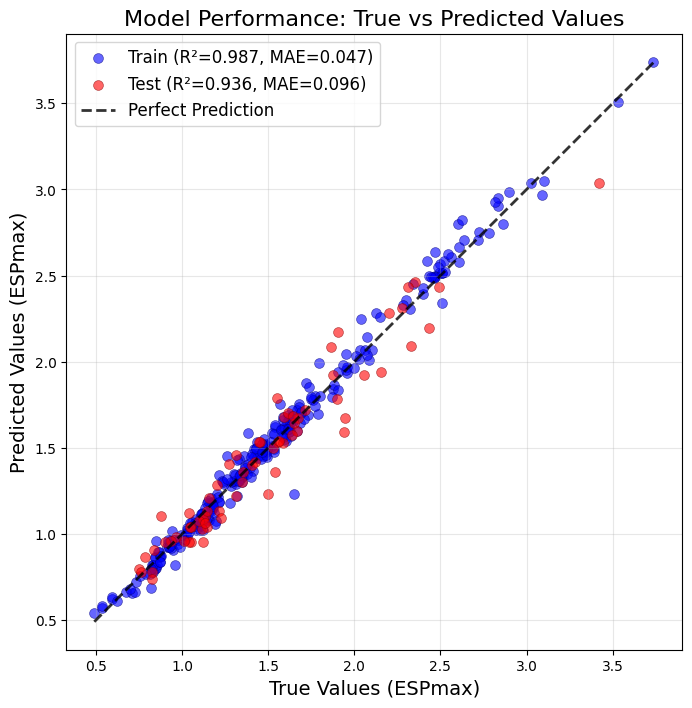

模型性能评估
训练集 (蓝色点):
  R² Score: 0.9872
  MAE: 0.0472
  RMSE: 0.0670
  样本数: 276

测试集 (红色点):
  R² Score: 0.9361
  MAE: 0.0962
  RMSE: 0.1295
  样本数: 68

整体性能:
  R² Score: 0.9792
  MAE: 0.0569
  RMSE: 0.0832
  总样本数: 344

图片已保存到: /home/hank/code/unimol_tools/predict dataset/ESP/single/ESPmax/combined_true_vs_predict.png

模型分析:
  训练集R²比测试集高 0.0511
  模型泛化性能良好


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set font fallback for plot rendering
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Calculate evaluation metrics.
def calculate_metrics(true_vals, pred_vals):
    r2 = r2_score(true_vals, pred_vals)
    mae = mean_absolute_error(true_vals, pred_vals)
    rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
    return r2, mae, rmse

# Calculate metrics for the training and test sets
r2_train, mae_train, rmse_train = calculate_metrics(true_values_train, predict_values_train)
r2_test, mae_test, rmse_test = calculate_metrics(true_values_test, predict_values_test)

# Create a single figure
plt.figure(figsize=(10, 8))

# Plot the training set
plt.scatter(true_values_train, predict_values_train, 
           alpha=0.6, s=50, color='blue', edgecolors='navy', linewidth=0.5,
           label=f'Train (R²={r2_train:.3f}, MAE={mae_train:.3f})')

# Plot the test set
plt.scatter(true_values_test, predict_values_test, 
           alpha=0.6, s=50, color='red', edgecolors='darkred', linewidth=0.5,
           label=f'Test (R²={r2_test:.3f}, MAE={mae_test:.3f})')

# Use the full data range to draw the parity line
all_true = np.concatenate([true_values_train, true_values_test])
all_pred = np.concatenate([predict_values_train, predict_values_test])
min_val = min(min(all_true), min(all_pred))
max_val = max(max(all_true), max(all_pred))

# Add the ideal prediction line
plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, alpha=0.8, label='Perfect Prediction')

# Set plot properties
plt.xlabel('True Values (ESPmax)', fontsize=14)
plt.ylabel('Predicted Values (ESPmax)', fontsize=14)
plt.title('Model Performance: True vs Predicted Values', fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Set axis limits with a small margin
margin = (max_val - min_val) * 0.05
plt.xlim(min_val - margin, max_val + margin)
plt.ylim(min_val - margin, max_val + margin)

# Keep equal axis scaling
plt.gca().set_aspect('equal', adjustable='box')

# Save the figure
output_image_path = work_file('predict_dataset', 'ESP', 'single', 'ESPmax', 'combined_true_vs_predict.png')
plt.savefig(output_image_path, dpi=300, bbox_inches='tight')

# Show the figure
plt.show()

# Print detailed evaluation metrics
print("="*60)
print("Model performance evaluation")
print("="*60)
print(f"Training set (blue points):")
print(f"  R² Score: {r2_train:.4f}")
print(f"  MAE: {mae_train:.4f}")
print(f"  RMSE: {rmse_train:.4f}")
print(f"  Sample count: {len(true_values_train)}")

print(f"\nTest set (red points):")
print(f"  R² Score: {r2_test:.4f}")
print(f"  MAE: {mae_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  Sample count: {len(true_values_test)}")

# Calculate overall performance across all data
r2_overall, mae_overall, rmse_overall = calculate_metrics(all_true, all_pred)
print(f"\nOverall performance:")
print(f"  R² Score: {r2_overall:.4f}")
print(f"  MAE: {mae_overall:.4f}")
print(f"  RMSE: {rmse_overall:.4f}")
print(f"  Total sample count: {len(all_true)}")

print(f"\nFigure saved to: {output_image_path}")

# Analyze possible overfitting
if r2_train > r2_test:
    overfitting = r2_train - r2_test
    print(f"\nModel analysis:")
    print(f"  Training-set R2 exceeds test-set R2 by {overfitting:.4f}")
    if overfitting > 0.1:
        print("  Some degree of overfitting may be present")
    else:
        print("  The model shows good generalization")
else:
    print(f"\nModel analysis:")
    print("  Test-set performance is not lower than training-set performance, indicating good generalization")